## 01. Conhecendo e realizando a primeira previsao com Prophet

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
from prophet import Prophet


In [2]:
dados = pd.read_csv('../data/poluentes.csv')
dados

,Data,PM2.5,PM10,SO2,NO2,CO,O3,TEMP
0,2020-03-01,7.0,11.0,12.0,23.0,429.0,64.0,1.0
1,2020-03-02,31.0,42.0,37.0,67.0,825.0,30.0,1.0
2,2020-03-03,77.0,121.0,61.0,81.0,1621.0,19.0,6.0
3,2020-03-04,23.0,45.0,23.0,46.0,606.0,54.0,10.0
4,2020-03-05,149.0,184.0,94.0,133.0,2358.0,68.0,6.0
...,...,...,...,...,...,...,...,...
1455,2024-02-24,22.0,33.0,17.0,59.0,575.0,51.0,5.0
1456,2024-02-25,11.0,20.0,7.0,43.0,421.0,66.0,7.0
1457,2024-02-26,28.0,41.0,10.0,65.0,721.0,49.0,7.0
1458,2024-02-27,75.0,97.0,21.0,98.0,1427.0,37.0,8.0


In [3]:
dados['Data'] = pd.to_datetime(dados['Data'])

In [4]:
fig = px.line(dados, x='Data', y='O3', title='Concentração de O3 ao longo do tempo')
fig.show()

In [5]:
# verificamos que há um padrão sazonal nos dados, com picos anuais na concentração de O3.
df_2022 = dados[dados['Data'].dt.year == 2022]

df_2022_mensal = df_2022.groupby(df_2022['Data'].dt.month)['O3'].mean().reset_index()

import calendar 

df_2022_mensal['Mês'] = df_2022_mensal['Data'].apply(lambda x: calendar.month_abbr[x])

fig = px.bar(df_2022_mensal, x='Mês', y='O3', title='Média Mensal de O3 ug/m3 em 2022')
fig.show()

In [6]:
df_prophet = pd.DataFrame()
df_prophet['ds'] = dados['Data']
df_prophet['y'] = dados['O3']

In [7]:
df_prophet

,ds,y
0,2020-03-01,64.0
1,2020-03-02,30.0
2,2020-03-03,19.0
3,2020-03-04,54.0
4,2020-03-05,68.0
...,...,...
1455,2024-02-24,51.0
1456,2024-02-25,66.0
1457,2024-02-26,49.0
1458,2024-02-27,37.0


In [8]:
# Instanciando o modelo
np.random.seed(4587)

modelo = Prophet()

# treinando o modelo
modelo.fit(df_prophet)

#criando datas futuras
futuro = modelo.make_future_dataframe(periods=365, freq='D')

# fazendo previsões
previsao = modelo.predict(futuro)

17:46:17 - cmdstanpy - INFO - Chain [1] start processing
17:46:17 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
from prophet.plot import plot_plotly, plot_components_plotly
fig = plot_plotly(modelo, previsao)
fig.show()

In [10]:
previsao

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-03-01,36.494406,-11.623363,49.668175,36.494406,36.494406,-17.561664,-17.561664,-17.561664,-2.094296,-2.094296,-2.094296,-15.467368,-15.467368,-15.467368,0.0,0.0,0.0,18.932742
1,2020-03-02,36.522762,-6.497430,53.983289,36.522762,36.522762,-13.457093,-13.457093,-13.457093,0.920265,0.920265,0.920265,-14.377358,-14.377358,-14.377358,0.0,0.0,0.0,23.065669
2,2020-03-03,36.551118,-7.388788,56.034143,36.551118,36.551118,-10.607200,-10.607200,-10.607200,2.599559,2.599559,2.599559,-13.206758,-13.206758,-13.206758,0.0,0.0,0.0,25.943918
3,2020-03-04,36.579474,-6.120727,55.330721,36.579474,36.579474,-11.789290,-11.789290,-11.789290,0.187277,0.187277,0.187277,-11.976567,-11.976567,-11.976567,0.0,0.0,0.0,24.790184
4,2020-03-05,36.607830,-3.579874,56.345704,36.607830,36.607830,-10.518297,-10.518297,-10.518297,0.190527,0.190527,0.190527,-10.708824,-10.708824,-10.708824,0.0,0.0,0.0,26.089533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,2025-02-23,61.701745,9.111877,68.718318,60.104959,63.117323,-21.543991,-21.543991,-21.543991,-2.094296,-2.094296,-2.094296,-19.449695,-19.449695,-19.449695,0.0,0.0,0.0,40.157755
1821,2025-02-24,61.698679,13.544675,73.317875,60.096353,63.123387,-18.280234,-18.280234,-18.280234,0.920265,0.920265,0.920265,-19.200499,-19.200499,-19.200499,0.0,0.0,0.0,43.418445
1822,2025-02-25,61.695613,16.200054,76.332978,60.087746,63.129353,-16.194486,-16.194486,-16.194486,2.599559,2.599559,2.599559,-18.794045,-18.794045,-18.794045,0.0,0.0,0.0,45.501127
1823,2025-02-26,61.692547,12.858245,72.994995,60.079140,63.131215,-18.046866,-18.046866,-18.046866,0.187277,0.187277,0.187277,-18.234143,-18.234143,-18.234143,0.0,0.0,0.0,43.645681


In [11]:
previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2020-03-01,18.932742,-11.623363,49.668175
1,2020-03-02,23.065669,-6.497430,53.983289
2,2020-03-03,25.943918,-7.388788,56.034143
3,2020-03-04,24.790184,-6.120727,55.330721
4,2020-03-05,26.089533,-3.579874,56.345704
...,...,...,...,...
1820,2025-02-23,40.157755,9.111877,68.718318
1821,2025-02-24,43.418445,13.544675,73.317875
1822,2025-02-25,45.501127,16.200054,76.332978
1823,2025-02-26,43.645681,12.858245,72.994995


In [12]:
# verificando os componentes da previsão

plot_components_plotly(modelo, previsao)

## 02. Analisando e aprofundando analise do Modelo

In [13]:
# Vamos separar os dadoos em treino e teste para avaliar a performance do modelo e evitar overfitting.
treino = int(len(df_prophet) * 0.8)
teste = int(len(df_prophet) * 0.2)
print(f'Tamanho do conjunto de treino: {treino}')
print(f'Tamanho do conjunto de teste: {teste}')

Tamanho do conjunto de treino: 1168
Tamanho do conjunto de teste: 292


In [14]:
df_treino = pd.DataFrame()

df_treino['ds'] = df_prophet['ds'][:treino]
df_treino['y'] = df_prophet['y'][:treino]

In [15]:
df_teste = pd.DataFrame()
df_teste['ds'] = df_prophet['ds'][treino:]
df_teste['y'] = df_prophet['y'][treino:]

In [16]:
np.random.seed(4587)

#instanciando o modelo
modelo = Prophet()

# treinando o modelo
modelo.fit(df_treino)

#criando datas futuras
futuro = modelo.make_future_dataframe(periods=teste, freq='D')

# fazendo previsões
previsao = modelo.predict(futuro)

17:46:19 - cmdstanpy - INFO - Chain [1] start processing
17:46:19 - cmdstanpy - INFO - Chain [1] done processing


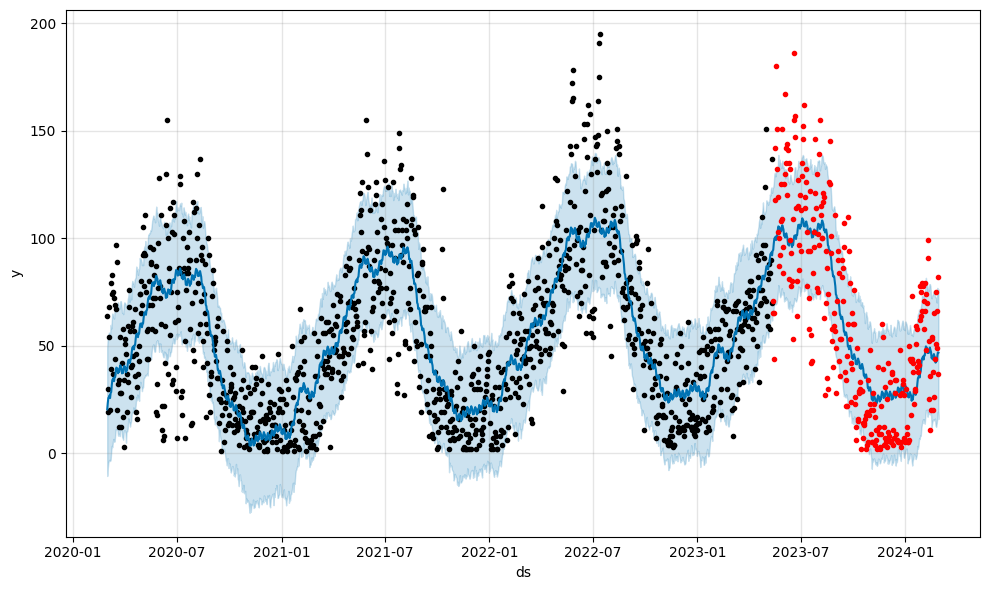

In [17]:
fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], 'r.')
plt.show()

In [18]:
df_previsa = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsa, df_teste, on='ds', how='inner')
df_comparacao

,ds,yhat,y
0,2023-05-13,94.175329,65.0
1,2023-05-14,94.520951,71.0
2,2023-05-15,97.580733,44.0
3,2023-05-16,99.861569,65.0
4,2023-05-17,100.140205,118.0
...,...,...,...
287,2024-02-24,43.298117,51.0
288,2024-02-25,42.799132,66.0
289,2024-02-26,45.151939,49.0
290,2024-02-27,46.876452,37.0


In [31]:
from sklearn.metrics import mean_squared_error

mse = round(mean_squared_error(df_comparacao['y'], df_comparacao['yhat']),2)
rmse = round(np.sqrt(mse), 2)
print(f"MSE:", mse)
print(f"RMSE:",  rmse)

MSE: 709.89
RMSE: 26.64


## 03. Melhorando o modelo e definindo parametros do prophet

In [ ]:
# Calculando os Limites superior e Inferior
np.random.seed(4587)
modelo = Prophet()
modelo.fit(df_prophet)
futuro = modelo.make_future_dataframe(periods=0, freq='D')
previsao = modelo.predict(futuro)

18:07:05 - cmdstanpy - INFO - Chain [1] start processing
18:07:06 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
# estou deixando apenas os dados que estão dentro dos limites, removendo os outliers
sem_outliers = df_prophet[(df_prophet['y'] > previsao['yhat_lower']) & (df_prophet['y'] < previsao['yhat_upper'])]
sem_outliers.reset_index(drop=True, inplace=True)

In [34]:
tamanho_treino = int(len(sem_outliers) * 0.8)
tamanho_teste = int(len(sem_outliers) * 0.2)
print(f'Tamanho do conjunto de treino sem outliers: {tamanho_treino}')
print(f'Tamanho do conjunto de teste sem outliers: {tamanho_teste}')    

Tamanho do conjunto de treino sem outliers: 961
Tamanho do conjunto de teste sem outliers: 240


In [35]:
df_treino_sem_outliers = pd.DataFrame()
df_treino_sem_outliers['ds'] = sem_outliers['ds'][:tamanho_treino]
df_treino_sem_outliers['y'] = sem_outliers['y'][:tamanho_treino]

In [36]:
df_teste_sem_outliers = pd.DataFrame()
df_teste_sem_outliers['ds'] = sem_outliers['ds'][tamanho_treino:]
df_teste_sem_outliers['y'] = sem_outliers['y'][tamanho_treino:]

In [ ]:
# Instaciar e treinar o modelo sem outliers
np.random.seed(4587)    
modelo = Prophet()
modelo.fit(df_treino_sem_outliers)
futuro = modelo.make_future_dataframe(periods=365, freq='D')
previsao = modelo.predict(futuro)